# 02 — Modelo final de demanda de taxis

Este notebook parte del dataset limpio y agregado que se genera en `022_modelo_batch.ipynb` y queda guardado en `../data_ml/df_ml`.

Aqui no se repite la limpieza ni la creacion de variables. El objetivo es cargar `df_ml`, aplicar los mejores hiperparametros obtenidos por validacion cruzada, comparar las familias de modelos en validation, reentrenar el mejor modelo con `train + validation` y guardarlo para streaming.

## Carga de `df_ml`

`df_ml` ya contiene la demanda agregada cada 15 minutos por zona, las variables temporales y los lags exactos usados por streaming: `lag_1` y `lag_2`.

In [3]:
from pathlib import Path
import json
import time

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import (
    LinearRegression,
    GeneralizedLinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor,
    GBTRegressor,
)
from pyspark.ml.evaluation import RegressionEvaluator

try:
    spark.stop()
except NameError:
    pass

spark = (
    SparkSession.builder
    .appName("nyc-taxi-final-model")
    .master("local[*]")
    .config("spark.executor.memory", "4g")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

df_ml = spark.read.parquet("../data_ml/df_ml")

print(f"df_ml cargado: {df_ml.count():,} filas")
df_ml.printSchema()

df_ml cargado: 251,877 filas
root
 |-- zone_lon: double (nullable = true)
 |-- zone_lat: double (nullable = true)
 |-- window_start: timestamp (nullable = true)
 |-- trip_count: long (nullable = true)
 |-- window_end: timestamp (nullable = true)
 |-- hour: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- dayofmonth: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_rush_hour: integer (nullable = true)
 |-- is_late_night: integer (nullable = true)
 |-- lag_1: long (nullable = true)
 |-- lag_2: long (nullable = true)



## 2.2 MODELOS ML

En esta libreta se parte de los mejores hiperparametros obtenidos en `022_modelo_batch.ipynb`. Cada familia se entrena con `train`, se compara en `validation` y el mejor modelo global se reentrena con `train + validation` antes de evaluarlo una sola vez sobre `test`.

### Preparacion del dataset para ML

Se usan exactamente las mismas variables que en la validacion cruzada y que en el consumidor de streaming.

In [4]:
feature_cols = [
    "zone_lon",
    "zone_lat",
    "hour",
    "dayofweek",
    "is_weekend",
    "is_rush_hour",
    "is_late_night",
    "lag_1",
    "lag_2",
]

label_col = "label"

missing_cols = [c for c in feature_cols + ["trip_count", "window_start"] if c not in df_ml.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas en df_ml: {missing_cols}")

df_model = (
    df_ml
    .select(*feature_cols, "trip_count", "window_start")
    .dropna()
    .withColumn(label_col, F.col("trip_count").cast("double"))
)

train_df = df_model.filter(F.col("window_start") < F.lit("2009-01-22 00:00:00").cast("timestamp"))
val_df = df_model.filter(
    (F.col("window_start") >= F.lit("2009-01-22 00:00:00").cast("timestamp"))
    & (F.col("window_start") < F.lit("2009-01-27 00:00:00").cast("timestamp"))
)
test_df = df_model.filter(F.col("window_start") >= F.lit("2009-01-27 00:00:00").cast("timestamp"))
train_val_df = train_df.unionByName(val_df)

for split_df in [train_df, val_df, test_df, train_val_df]:
    split_df.cache()

split_counts = pd.DataFrame([
    {"split": "train", "filas": train_df.count()},
    {"split": "validation", "filas": val_df.count()},
    {"split": "test", "filas": test_df.count()},
    {"split": "train+validation", "filas": train_val_df.count()},
])

display(split_counts)

,split,filas
0,train,169203
1,validation,41717
2,test,40957
3,train+validation,210920


### Entrenamiento y comparacion de familias

Se evalua cada modelo con sus mejores parametros sobre `train` y `validation`. La seleccion global se hace por MAE de validacion, porque es la metrica mas interpretable para la demanda: error medio en numero de viajes.

In [6]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

fallback_best_params = {
    "Regresion lineal": {"regParam": 0.1, "elasticNetParam": 0.0},
    "Regresion Poisson": {"regParam": 0.1},
    "Decision Tree": {"maxDepth": 12, "minInstancesPerNode": 1},
    "Random Forest": {"numTrees": 80, "maxDepth": 12, "minInstancesPerNode": 1},
    "Gradient-Boosted Trees": {"maxIter": 120, "maxDepth": 6, "stepSize": 0.1},
}

params_path = Path("../models/cv_best_params.json")
if params_path.exists():
    with open(params_path, "r", encoding="utf-8") as f:
        best_params_by_model = json.load(f)
else:
    best_params_by_model = fallback_best_params


def build_estimator(model_name, params):
    if model_name == "Regresion lineal":
        return LinearRegression(featuresCol="features", labelCol=label_col, maxIter=50, **params)
    if model_name == "Regresion Poisson":
        return GeneralizedLinearRegression(
            featuresCol="features",
            labelCol=label_col,
            family="poisson",
            link="log",
            maxIter=50,
            **params,
        )
    if model_name == "Decision Tree":
        return DecisionTreeRegressor(featuresCol="features", labelCol=label_col, seed=42, **params)
    if model_name == "Random Forest":
        return RandomForestRegressor(featuresCol="features", labelCol=label_col, seed=42, **params)
    if model_name == "Gradient-Boosted Trees":
        return GBTRegressor(featuresCol="features", labelCol=label_col, seed=42, **params)
    raise ValueError(f"Modelo no soportado: {model_name}")


def evaluate_predictions(model_name, split_name, predictions, params, train_time_seconds):
    evaluators = {
        "RMSE": RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="rmse"),
        "MAE": RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="mae"),
        "R2": RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="r2"),
    }
    row = {
        "modelo": model_name,
        "split": split_name,
        "training_time_seconds": train_time_seconds,
        "params": params,
    }
    for metric_name, evaluator in evaluators.items():
        row[metric_name] = evaluator.evaluate(predictions)
    return row


trained_models = {}
comparison_rows = []

for model_name, params in best_params_by_model.items():
    estimator = build_estimator(model_name, params)
    pipeline = Pipeline(stages=[assembler, estimator])

    start = time.perf_counter()
    model = pipeline.fit(train_df)
    elapsed = time.perf_counter() - start
    trained_models[model_name] = model

    comparison_rows.append(evaluate_predictions(model_name, "train", model.transform(train_df), params, elapsed))
    comparison_rows.append(evaluate_predictions(model_name, "validation", model.transform(val_df), params, elapsed))

comparison_pdf = pd.DataFrame(comparison_rows).sort_values(["split", "MAE"])
validation_comparison_pdf = comparison_pdf[comparison_pdf["split"] == "validation"].sort_values("MAE")

best_model_name = validation_comparison_pdf.iloc[0]["modelo"]
best_model_params = best_params_by_model[best_model_name]

display(comparison_pdf)
print(f"Mejor modelo global segun MAE en validation: {best_model_name}")
print(f"Parametros: {best_model_params}")

26/05/11 17:12:52 WARN DAGScheduler: Broadcasting large task binary with size 1593.1 KiB
26/05/11 17:12:53 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/05/11 17:12:56 WARN DAGScheduler: Broadcasting large task binary with size 5.8 MiB
26/05/11 17:13:00 WARN DAGScheduler: Broadcasting large task binary with size 1814.5 KiB
26/05/11 17:13:01 WARN DAGScheduler: Broadcasting large task binary with size 10.9 MiB
26/05/11 17:13:06 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/05/11 17:13:08 WARN DAGScheduler: Broadcasting large task binary with size 19.7 MiB
26/05/11 17:13:14 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
26/05/11 17:13:18 WARN DAGScheduler: Broadcasting large task binary with size 34.3 MiB
26/05/11 17:13:26 WARN DAGScheduler: Broadcasting large task binary with size 8.9 MiB
26/05/11 17:14:11 WARN DAGScheduler: Broadcasting large task binary with size 1000.3 KiB
26/05/11 17:14:11 WARN DAGScheduler: Broad

,modelo,split,training_time_seconds,params,RMSE,MAE,R2
4,Decision Tree,train,1.898250,"{'maxDepth': 12, 'minInstancesPerNode': 1}",12.695447,6.687586,0.976170
8,Gradient-Boosted Trees,train,56.728871,"{'maxIter': 120, 'maxDepth': 6, 'stepSize': 0.1}",12.429505,6.697055,0.977158
6,Random Forest,train,42.018243,"{'numTrees': 80, 'maxDepth': 12, 'minInstances...",12.858816,6.734043,0.975553
0,Regresion lineal,train,0.864778,"{'regParam': 0.1, 'elasticNetParam': 0.0}",13.572254,7.558834,0.972765
2,Regresion Poisson,train,1.603359,{'regParam': 0.1},102.443415,32.271828,-0.551641
9,Gradient-Boosted Trees,validation,56.728871,"{'maxIter': 120, 'maxDepth': 6, 'stepSize': 0.1}",14.227217,7.384992,0.975409
7,Random Forest,validation,42.018243,"{'numTrees': 80, 'maxDepth': 12, 'minInstances...",14.495199,7.457709,0.974474
5,Decision Tree,validation,1.898250,"{'maxDepth': 12, 'minInstancesPerNode': 1}",15.226251,7.774661,0.971835
1,Regresion lineal,validation,0.864778,"{'regParam': 0.1, 'elasticNetParam': 0.0}",13.982990,7.844190,0.976246
3,Regresion Poisson,validation,1.603359,{'regParam': 0.1},127.435541,34.886313,-0.972917


Mejor modelo global segun MAE en validation: Gradient-Boosted Trees
Parametros: {'maxIter': 120, 'maxDepth': 6, 'stepSize': 0.1}


In [7]:
import numpy as np

def permutation_importance(model, df, feature_cols, label_col, metric="rmse", n_repeats=3, seed=42):
    evaluator = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName=metric)
   
    baseline_score = evaluator.evaluate(model.transform(df))
   
    results = []
    rng = np.random.default_rng(seed)
   
    for feat in feature_cols:
        scores = []
        for i in range(n_repeats):
            # Permuta la columna: sample sin reemplazo = shuffle
            permuted_df = df.withColumn(feat, F.col(feat).cast("double"))
           
            # Recoger los valores, shufflearlos, y hacer un join por índice artificial
            vals = [row[feat] for row in df.select(feat).collect()]
            rng.shuffle(vals)
           
            # Crear df con índice + valor permutado
            spark_vals = spark.createDataFrame(
                [(i, float(v)) for i, v in enumerate(vals)],
                ["_idx", feat]
            )
            # Añadir índice al df original
            permuted_df = df.withColumn("_idx", F.monotonically_increasing_id())
            # Quitar la columna original y hacer join con la permutada
            permuted_df = permuted_df.drop(feat).join(spark_vals, on="_idx").drop("_idx")
           
            score = evaluator.evaluate(model.transform(permuted_df))
            scores.append(score)
       
        mean_score = np.mean(scores)
        results.append({
            "feature": feat,
            "baseline_rmse": baseline_score,
            "permuted_rmse_mean": mean_score,
            "importance": mean_score - baseline_score  # cuánto sube el error al permutar
        })
   
    return pd.DataFrame(results).sort_values("importance", ascending=False)

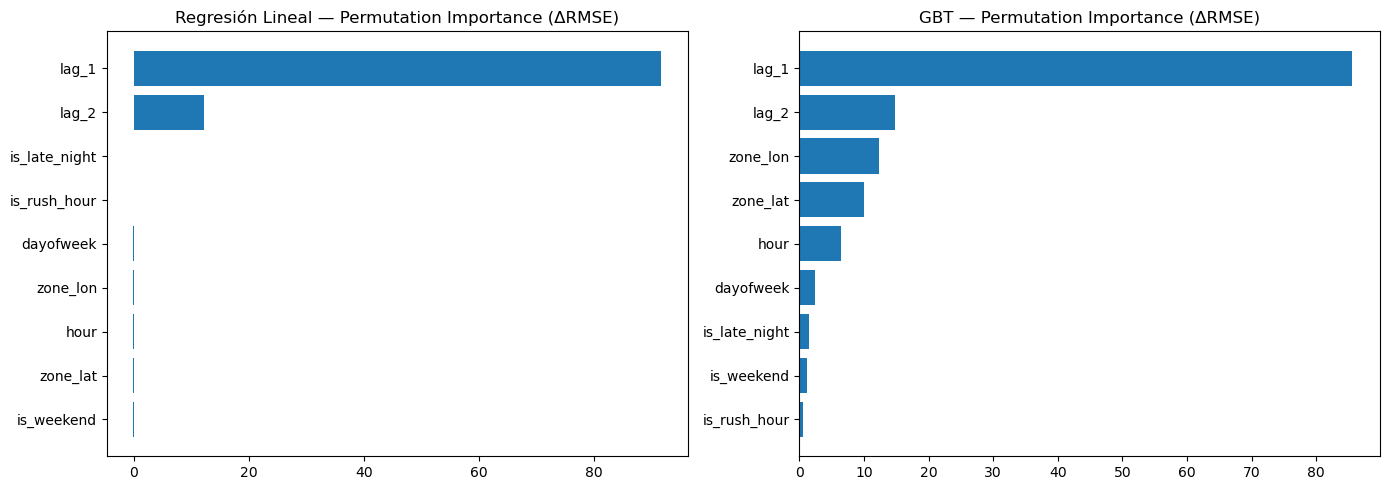

In [8]:
from pyspark.sql import functions as F

pi_lr  = permutation_importance(trained_models["Regresion lineal"], val_df, feature_cols, label_col)
pi_gbt = permutation_importance(trained_models["Gradient-Boosted Trees"], val_df, feature_cols, label_col)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(pi_lr["feature"], pi_lr["importance"])
axes[0].set_title("Regresión Lineal — Permutation Importance (ΔRMSE)")
axes[0].invert_yaxis()

axes[1].barh(pi_gbt["feature"], pi_gbt["importance"])
axes[1].set_title("GBT — Permutation Importance (ΔRMSE)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [9]:
from pyspark.sql import functions as F

def error_by_quantile(model, df, label_col, n_buckets=4):
    preds = model.transform(df)
    preds = preds.withColumn("abs_error", F.abs(F.col("prediction") - F.col(label_col)))
   
    quantiles = df.approxQuantile(label_col, [i/n_buckets for i in range(1, n_buckets)], 0.01)
   
    def get_bucket(val):
        for i, q in enumerate(quantiles):
            if val <= q:
                return i
        return n_buckets - 1
   
    get_bucket_udf = F.udf(get_bucket)
    preds = preds.withColumn("bucket", get_bucket_udf(F.col(label_col)))
   
    return preds.groupBy("bucket").agg(
        F.mean("abs_error").alias("MAE"),
        F.mean(label_col).alias("mean_demand"),
        F.count("*").alias("count")
    ).orderBy("bucket")

error_by_quantile(trained_models["Regresion lineal"], val_df, label_col).show()
error_by_quantile(trained_models["Gradient-Boosted Trees"], val_df, label_col).show()

+------+-----------------+------------------+-----+
|bucket|              MAE|       mean_demand|count|
+------+-----------------+------------------+-----+
|     0|2.167523412739485| 1.778034583119329|11682|
|     1| 3.02562298267654| 6.569562446898895| 9416|
|     2|7.227335038180641|31.826366559485532| 9952|
|     3|18.88997293716385| 180.1919940001875|10667|
+------+-----------------+------------------+-----+

+------+------------------+------------------+-----+
|bucket|               MAE|       mean_demand|count|
+------+------------------+------------------+-----+
|     0|1.3559602009578338| 1.778034583119329|11682|
|     1| 2.457695348191468| 6.569562446898895| 9416|
|     2| 6.714435546851848|31.826366559485532| 9952|
|     3| 18.96274886278542| 180.1919940001875|10667|
+------+------------------+------------------+-----+



### Reentrenamiento final y evaluacion en test

Una vez elegido el modelo global, se reentrena con `train + validation`. El conjunto `test` queda reservado para medir el resultado final sin haber participado en la seleccion.

In [10]:
final_estimator = build_estimator(best_model_name, best_model_params)
final_pipeline = Pipeline(stages=[assembler, final_estimator])

start = time.perf_counter()
final_model = final_pipeline.fit(train_val_df)
final_train_time = time.perf_counter() - start

test_predictions = final_model.transform(test_df)
test_result = evaluate_predictions(
    best_model_name,
    "test",
    test_predictions,
    best_model_params,
    final_train_time,
)

test_results_pdf = pd.DataFrame([test_result])
display(test_results_pdf)

test_predictions.select(
    "window_start",
    "zone_lon",
    "zone_lat",
    "trip_count",
    "prediction",
).orderBy(F.col("prediction").desc()).show(20, truncate=False)

26/05/11 17:31:51 WARN DAGScheduler: Broadcasting large task binary with size 1000.7 KiB
26/05/11 17:31:51 WARN DAGScheduler: Broadcasting large task binary with size 1005.3 KiB
26/05/11 17:31:51 WARN DAGScheduler: Broadcasting large task binary with size 1008.6 KiB
26/05/11 17:31:51 WARN DAGScheduler: Broadcasting large task binary with size 1009.1 KiB
26/05/11 17:31:51 WARN DAGScheduler: Broadcasting large task binary with size 1009.8 KiB
26/05/11 17:31:51 WARN DAGScheduler: Broadcasting large task binary with size 1010.8 KiB
26/05/11 17:31:51 WARN DAGScheduler: Broadcasting large task binary with size 1013.1 KiB
26/05/11 17:31:51 WARN DAGScheduler: Broadcasting large task binary with size 1017.6 KiB
26/05/11 17:31:52 WARN DAGScheduler: Broadcasting large task binary with size 1020.8 KiB
26/05/11 17:31:52 WARN DAGScheduler: Broadcasting large task binary with size 1021.2 KiB
26/05/11 17:31:52 WARN DAGScheduler: Broadcasting large task binary with size 1022.0 KiB
26/05/11 17:31:52 WAR

,modelo,split,training_time_seconds,params,RMSE,MAE,R2
0,Gradient-Boosted Trees,test,77.818907,"{'maxIter': 120, 'maxDepth': 6, 'stepSize': 0.1}",14.573672,7.471035,0.976329


+-------------------+--------+--------+----------+-----------------+
|window_start       |zone_lon|zone_lat|trip_count|prediction       |
+-------------------+--------+--------+----------+-----------------+
|2009-01-27 19:15:00|-73.98  |40.75   |799       |717.4321019676237|
|2009-01-27 19:30:00|-73.98  |40.75   |803       |717.4321019676237|
|2009-01-27 19:00:00|-73.98  |40.75   |799       |717.4321019676237|
|2009-01-27 19:45:00|-73.98  |40.75   |813       |717.4321019676237|
|2009-01-27 18:00:00|-73.98  |40.75   |733       |704.7654318992566|
|2009-01-27 18:30:00|-73.98  |40.75   |772       |704.7654318992566|
|2009-01-27 18:45:00|-73.98  |40.75   |753       |704.7654318992566|
|2009-01-27 18:15:00|-73.98  |40.75   |753       |704.7654318992566|
|2009-01-28 20:30:00|-73.98  |40.75   |739       |681.5032156031002|
|2009-01-28 20:15:00|-73.98  |40.75   |697       |681.5032156031002|
|2009-01-28 20:45:00|-73.98  |40.75   |620       |681.5032156031002|
|2009-01-28 20:00:00|-73.98  |40.7

### Guardado del modelo final

El modelo final se guarda como `PipelineModel` para poder cargarlo directamente desde Spark Streaming.

In [11]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

final_model_path = models_dir / "best_demand_model"
final_model.write().overwrite().save(str(final_model_path))

metadata = {
    "best_model_name": best_model_name,
    "best_params": best_model_params,
    "feature_cols": feature_cols,
    "label_col": label_col,
    "train_until": "2009-01-22 00:00:00",
    "validation_from": "2009-01-22 00:00:00",
    "validation_until": "2009-01-27 00:00:00",
    "test_from": "2009-01-27 00:00:00",
    "test_metrics": test_result,
}

with open(models_dir / "best_demand_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)


print(f"Modelo final guardado en {final_model_path}")

Modelo final guardado en ../models/best_demand_model


# CONCLUSIONES

| Modelo | Split | RMSE | MAE | R² | Tiempo (s) | Notas |
|---|---|---|---|---|---|---|
| Gradient-Boosted Trees | train | 12.43 | 6.70 | 0.9772 | 56.7 | Mejor modelo en train. Ensemble secuencial de 120 iteraciones con maxDepth=6 controlado para evitar overfitting. |
| Decision Tree | train | 12.70 | 6.69 | 0.9762 | 1.9 | Competitivo en train gracias a la fuerte señal de lag_1. Mucho más rápido que los ensembles. |
| Random Forest | train | 12.86 | 6.73 | 0.9756 | 42.0 | Ligeramente por debajo del GBT en train a pesar de usar más árboles (80). |
| Regresión Lineal | train | 13.57 | 7.56 | 0.9728 | 0.9 | Buen resultado para un modelo tan simple. Refleja que lag_1 tiene correlación casi lineal con el target. |
| Regresión Poisson | train | 102.44 | 32.27 | -0.5516 | 1.6 | Fallo total. Ver nota. |
| **Gradient-Boosted Trees** | **validation** | **14.23** | **7.38** | **0.9754** | 56.7 | **Modelo seleccionado. Ver justificación.** |
| Random Forest | validation | 14.50 | 7.46 | 0.9745 | 42.0 | Segunda mejor opción. Gap train/val similar al GBT. |
| Regresión Lineal | validation | 13.98 | 7.84 | 0.9762 | 0.9 | RMSE ligeramente inferior al GBT en validación, pero descartada. Ver justificación. |
| Decision Tree | validation | 15.23 | 7.77 | 0.9718 | 1.9 | Mayor gap train/val de los modelos competitivos, señal de overfitting leve. |
| Regresión Poisson | validation | 127.44 | 34.89 | -0.9729 | 1.6 | Fallo total. Ver nota. |

---

### REGRESSION POISSON NOTAS

Un R² negativo significa que el modelo es peor que predecir siempre la media del target — el peor resultado posible. La causa es **sobredispersión extrema**: Poisson asume que la varianza del target es igual a su media (`Var(Y) = E(Y)`). En este dataset, la media de viajes por zona y ventana es ~54 pero la desviación estándar es ~130, lo que da una ratio varianza/media de **~313**. Poisson está diseñado para conteos con ratio próximo a 1.

Adicionalmente, Spark implementa Poisson GLM minimizando la *deviance de Poisson*, no el MSE. El modelo converge a parámetros óptimos bajo esa función de pérdida, pero esos parámetros generan predicciones desastrosas cuando se evalúan con RMSE/R², que es una métrica completamente distinta. El resultado empeora en validación (R² = -0.97) porque la sobredispersión de la cola de alta demanda penaliza aún más al modelo fuera del training.

---

### GBT SOBRE REG.LINEAL NOTAS

La regresión lineal obtiene un RMSE en validación ligeramente inferior al GBT (13.98 vs 14.23), lo que podría sugerir que es el mejor modelo. Este resultado se explica por la naturaleza del problema: `lag_1` — la demanda real de la zona 15 minutos antes — lleva implícita casi toda la información espaciotemporal relevante. En ventanas de 15 minutos la demanda raramente cambia de forma brusca, por lo que cualquier modelo que aprenda a seguir el lag obtiene un R² cercano a 0.97. La regresión lineal explota exactamente eso: aprende una relación casi proporcional entre `lag_1` y el target, e ignora el resto de features — su permutation importance muestra que `zone_lon`, `zone_lat` y `hour` tienen importancia prácticamente nula.

El problema de la lineal aparece en el 3% de casos donde el lag no es suficiente: transiciones temporales bruscas en zonas de alta demanda, como el inicio del rush hour del lunes en una zona céntrica, donde la demanda puede triplicarse en una sola ventana. En esos casos la lineal no puede combinar "esta zona" + "esta hora" + "este día de la semana" porque no modela interacciones entre features. GBT sí: mediante sus splits aprende que ciertas combinaciones espaciotemporales implican demanda alta independientemente del lag. Esto se confirma en el análisis por cuartil de demanda, donde GBT gana consistentemente en los tres primeros buckets (75% de los datos), y solo empata con la lineal en el bucket de alta demanda donde los árboles tienen menos ejemplos de entrenamiento.

En consecuencia, GBT es la elección correcta no porque gane con holgura en validación, sino porque entiende el problema completo. Con más datos históricos — varios meses, distintas estaciones — la diferencia crecería, ya que habría más patrones espaciotemporales que aprender. En un entorno de streaming real donde los patrones pueden variar, un modelo que solo sigue el lag es estructuralmente frágil.